In [1]:
import pandas as pd
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.config as config
import src.profile_model_registry as profile_model_registry
import src.profile_tracker as profile_tracker
import src.profile_trainer as profile_trainer

importlib.reload(config)
importlib.reload(profile_model_registry)
importlib.reload(profile_tracker)
importlib.reload(profile_trainer)

from src.profile_trainer import run_profile_training_experiment

print(profile_model_registry.get_profile_dense_models().keys())
print(profile_model_registry.get_profile_nan_friendly_models().keys())

dict_keys(['ridge', 'random_forest', 'xgboost', 'catboost'])
dict_keys(['hist_gbr', 'xgboost'])


In [2]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.profile_dataset_builder import build_day_ahead_profile_dataset
from src.profile_metrics import evaluate_profile_global

In [5]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\30_min\df_BU_TotActPwr_Academy.parquet"
df_imputed = pd.read_parquet(path)

In [6]:
target_col = "BU_TotActPwr_Academy"
feature_cols = [c for c in df_imputed.columns if c != target_col]

## check ML model after drop 1st week feb

In [7]:
X, Y_full = build_day_ahead_profile_dataset(
    df_imputed,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=48,
    issue_hour=23,
    issue_minute=30,
    drop_feature_nan=False,
    drop_target_nan=True,
)

print("X:", X.shape)
print("Y_full:", Y_full.shape)
print("Issue range:", X.index.min(), "to", X.index.max())

X: (110, 37)
Y_full: (110, 48)
Issue range: 2025-10-21 23:30:00 to 2026-02-07 23:30:00


In [8]:
# Test target days: Jan 24 to Jan 31
# Issue time Jan 23 23:45 predicts Jan 24
# Issue time Jan 30 23:45 predicts Jan 31

test_issue_start = pd.Timestamp("2026-01-18 23:30:00")
test_issue_end   = pd.Timestamp("2026-01-25 23:30:00")

# Drop Feb regime by simply not using issue times after Jan 30 23:45
train_mask = X.index < test_issue_start
test_mask = (X.index >= test_issue_start) & (X.index <= test_issue_end)

X_train_jan = X.loc[train_mask].copy()
Y_train_jan = Y_full.loc[train_mask].copy()

X_test_jan = X.loc[test_mask].copy()
Y_test_jan = Y_full.loc[test_mask].copy()

print("Train issue range:", X_train_jan.index.min(), "to", X_train_jan.index.max())
print("Test issue range :", X_test_jan.index.min(), "to", X_test_jan.index.max())

print("X_train_jan:", X_train_jan.shape)
print("Y_train_jan:", Y_train_jan.shape)
print("X_test_jan :", X_test_jan.shape)
print("Y_test_jan :", Y_test_jan.shape)

Train issue range: 2025-10-21 23:30:00 to 2026-01-17 23:30:00
Test issue range : 2026-01-18 23:30:00 to 2026-01-25 23:30:00
X_train_jan: (89, 37)
Y_train_jan: (89, 48)
X_test_jan : (8, 37)
Y_test_jan : (8, 48)


In [9]:
xgb_base = XGBRegressor(
    n_estimators=800,
    max_depth=3,
    learning_rate=0.001,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=2.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

model_jan = MultiOutputRegressor(xgb_base)

model_jan.fit(X_train_jan, Y_train_jan)

Y_pred_jan = model_jan.predict(X_test_jan)

In [10]:
jan_full_metrics = evaluate_profile_global(Y_test_jan, Y_pred_jan)

pd.DataFrame([{
    "experiment": "diagnostic_train_before_jan24_test_jan24_31",
    **jan_full_metrics,
}])

,experiment,MAE,RMSE,MAPE,sMAPE,R2
0,diagnostic_train_before_jan24_test_jan24_31,1.492823,2.353817,17.363203,17.436972,0.781097


In [11]:
def time_to_step(hour, minute=0, freq_minutes=30):
    return (hour * 60 + minute) // freq_minutes + 1


def evaluate_window(Y_test, Y_pred, start_hour, end_hour, freq_minutes=30):
    start_step = time_to_step(start_hour, 0, freq_minutes)
    end_step = time_to_step(end_hour, 0, freq_minutes) - 1

    cols = [f"y_tplus_{s:03d}" for s in range(start_step, end_step + 1)]
    idx = [Y_test.columns.get_loc(c) for c in cols]

    y_true = Y_test.iloc[:, idx].values.ravel()
    y_pred = Y_pred[:, idx].ravel()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mape_mask = y_true != 0
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_mask = denom != 0

    return {
        "window": f"{start_hour:02d}:00-{end_hour:02d}:00",
        "start_step": start_step,
        "end_step": end_step,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": np.mean(np.abs((y_true[mape_mask] - y_pred[mape_mask]) / y_true[mape_mask])) * 100,
        "sMAPE": np.mean(np.abs(y_true[smape_mask] - y_pred[smape_mask]) / denom[smape_mask]) * 100,
        "R2": r2_score(y_true, y_pred),
        "bias_pred_minus_actual": np.mean(y_pred - y_true),
        "actual_mean": np.mean(y_true),
        "pred_mean": np.mean(y_pred),
        "actual_max": np.max(y_true),
        "pred_max": np.max(y_pred),
    }

In [12]:
windows = [
    (8, 17),
    (9, 17),
    (10, 17),
    (10, 18),
]

jan_window_results = pd.DataFrame([
    {
        "experiment": "jan24_31_test",
        **evaluate_window(Y_test_jan, Y_pred_jan, start_h, end_h),
    }
    for start_h, end_h in windows
])

jan_window_results

,experiment,window,start_step,end_step,MAE,RMSE,MAPE,sMAPE,R2,bias_pred_minus_actual,actual_mean,pred_mean,actual_max,pred_max
0,jan24_31_test,08:00-17:00,17,34,2.897283,3.676640,23.712612,22.653673,0.335971,-0.741799,12.997207,12.255408,23.5245,14.568826
1,jan24_31_test,09:00-17:00,19,34,3.041243,3.832510,23.801546,23.086099,0.286445,-1.010983,13.433663,12.422680,23.5245,14.568826
2,jan24_31_test,10:00-17:00,21,34,3.213346,3.992641,24.187080,23.851134,0.258873,-1.274862,13.764519,12.489656,23.5245,14.568826
3,jan24_31_test,10:00-18:00,21,36,2.881296,3.743227,22.789724,22.343290,0.497728,-1.073301,12.629240,11.555938,23.5245,14.568826


In [13]:
comparison_diagnostic = pd.DataFrame([
    {
        "period": "Feb_1_8",
        "scope": "full_day",
        "MAE": 2.183638,
        "RMSE": 3.834135,
        "MAPE": 17.831199,
        "sMAPE": 18.595342,
        "R2": 0.775180,
    },
    {
        "period": "Jan_24_31",
        "scope": "full_day",
        **jan_full_metrics,
    },
])

comparison_diagnostic

,period,scope,MAE,RMSE,MAPE,sMAPE,R2
0,Feb_1_8,full_day,2.183638,3.834135,17.831199,18.595342,0.775180
1,Jan_24_31,full_day,1.492823,2.353817,17.363203,17.436972,0.781097


In [14]:
jan_peak_10_18 = jan_window_results[jan_window_results["window"] == "10:00-18:00"].iloc[0].to_dict()

comparison_peak_diagnostic = pd.DataFrame([
    {
        "period": "Feb_1_8",
        "scope": "10:00-18:00",
        "MAE": 4.455090,
        "RMSE": 6.032092,
        "MAPE": 24.206319,
        "sMAPE": 25.643545,
        "R2": 0.482705,
        "bias_pred_minus_actual": -2.903382,
        "actual_mean": 16.864540,
        "pred_mean": 13.961159,
        "actual_max": 37.11933,
        "pred_max": 25.38801,
    },
    {
        "period": "Jan_24_31",
        "scope": "10:00-18:00",
        "MAE": jan_peak_10_18["MAE"],
        "RMSE": jan_peak_10_18["RMSE"],
        "MAPE": jan_peak_10_18["MAPE"],
        "sMAPE": jan_peak_10_18["sMAPE"],
        "R2": jan_peak_10_18["R2"],
        "bias_pred_minus_actual": jan_peak_10_18["bias_pred_minus_actual"],
        "actual_mean": jan_peak_10_18["actual_mean"],
        "pred_mean": jan_peak_10_18["pred_mean"],
        "actual_max": jan_peak_10_18["actual_max"],
        "pred_max": jan_peak_10_18["pred_max"],
    },
])

comparison_peak_diagnostic

,period,scope,MAE,RMSE,MAPE,sMAPE,R2,bias_pred_minus_actual,actual_mean,pred_mean,actual_max,pred_max
0,Feb_1_8,10:00-18:00,4.455090,6.032092,24.206319,25.643545,0.482705,-2.903382,16.86454,13.961159,37.11933,25.388010
1,Jan_24_31,10:00-18:00,2.881296,3.743227,22.789724,22.343290,0.497728,-1.073301,12.62924,11.555938,23.52450,14.568826


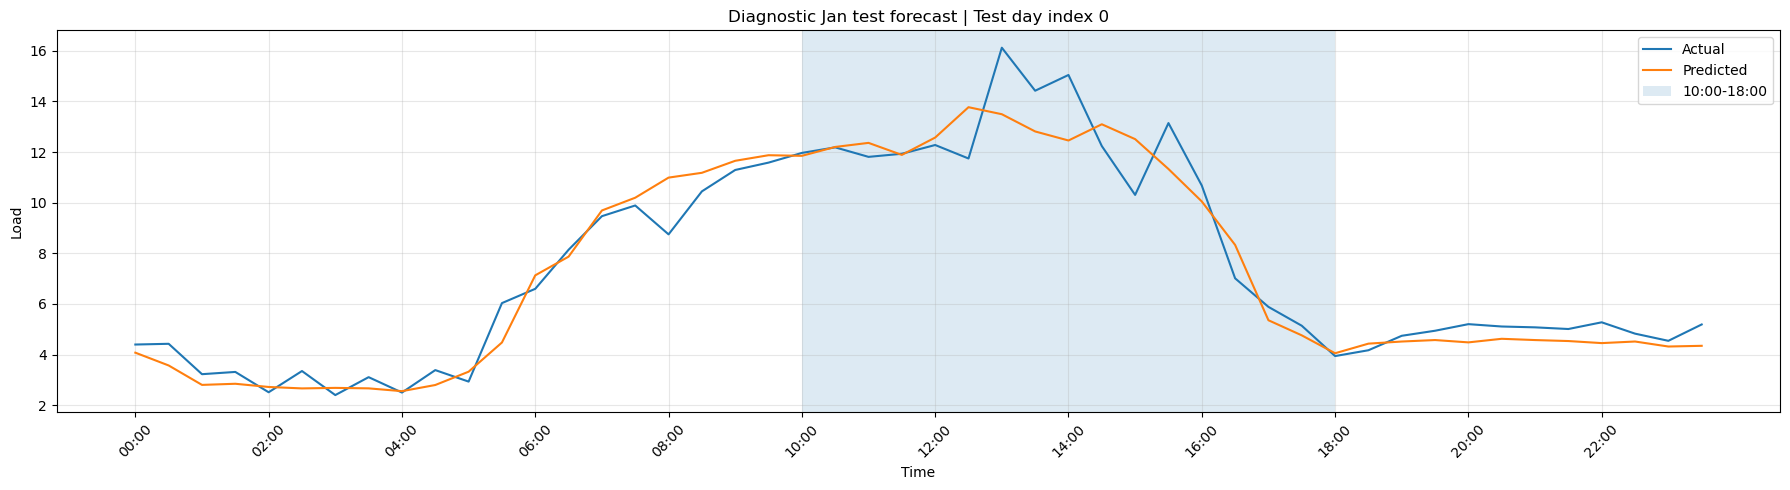

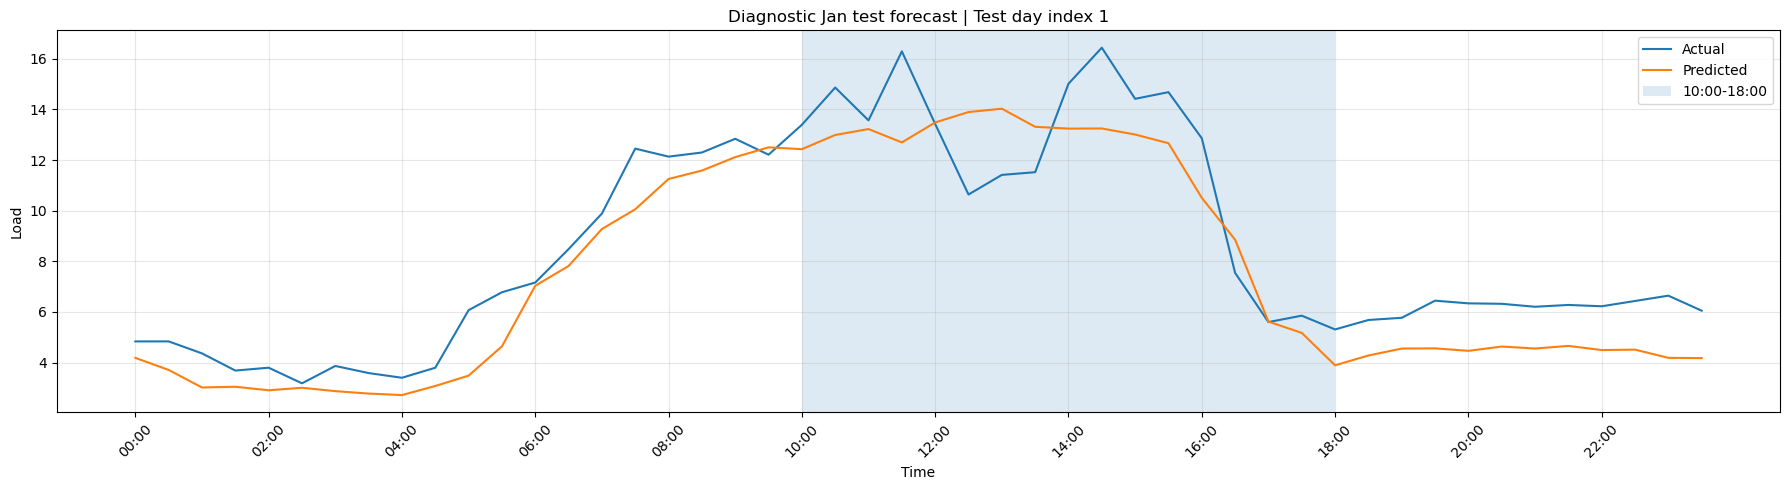

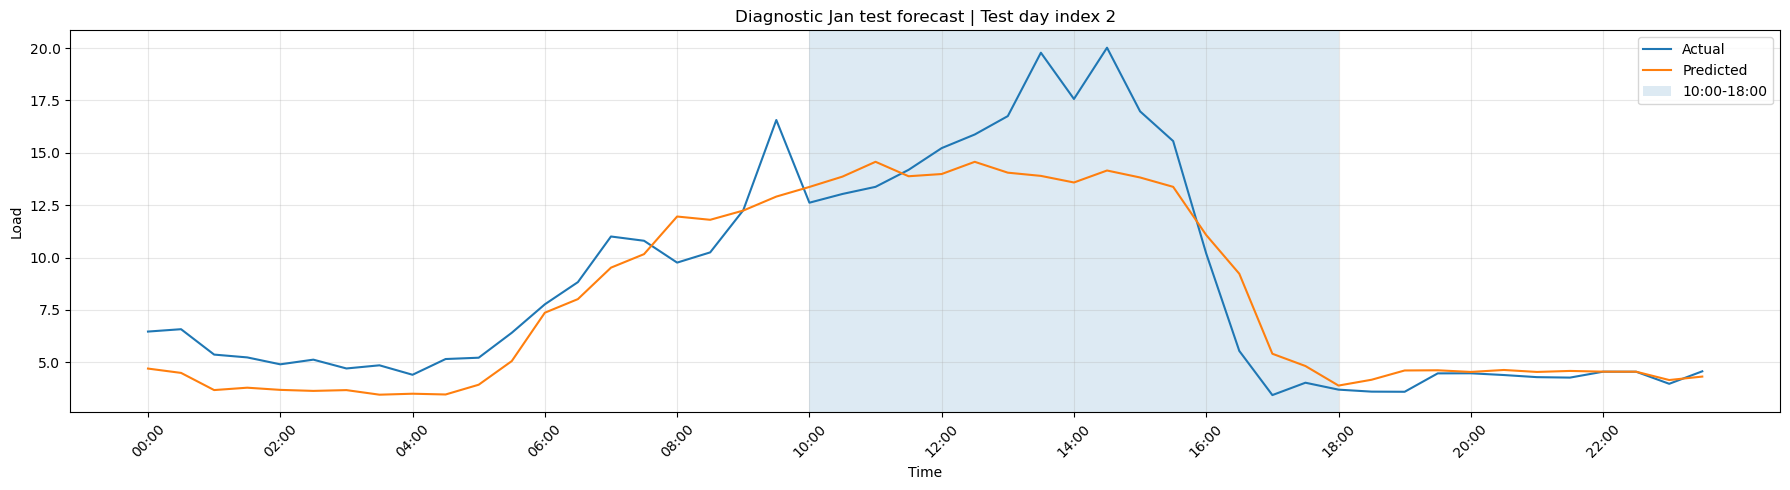

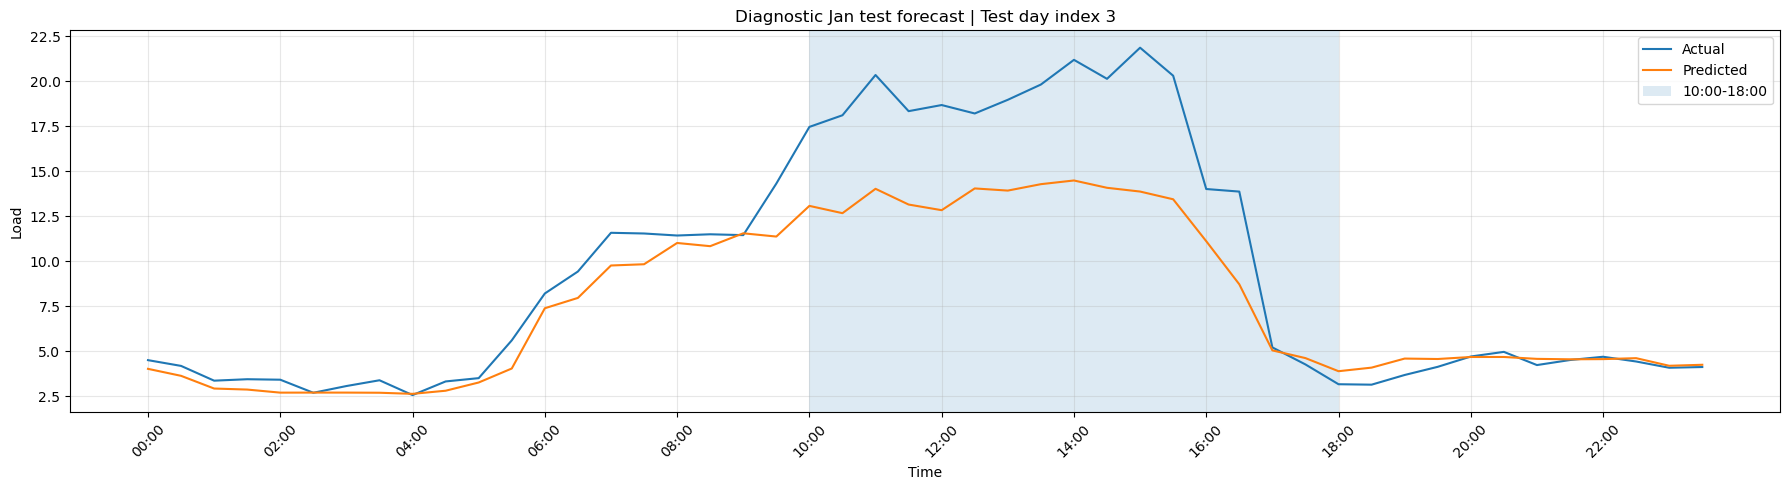

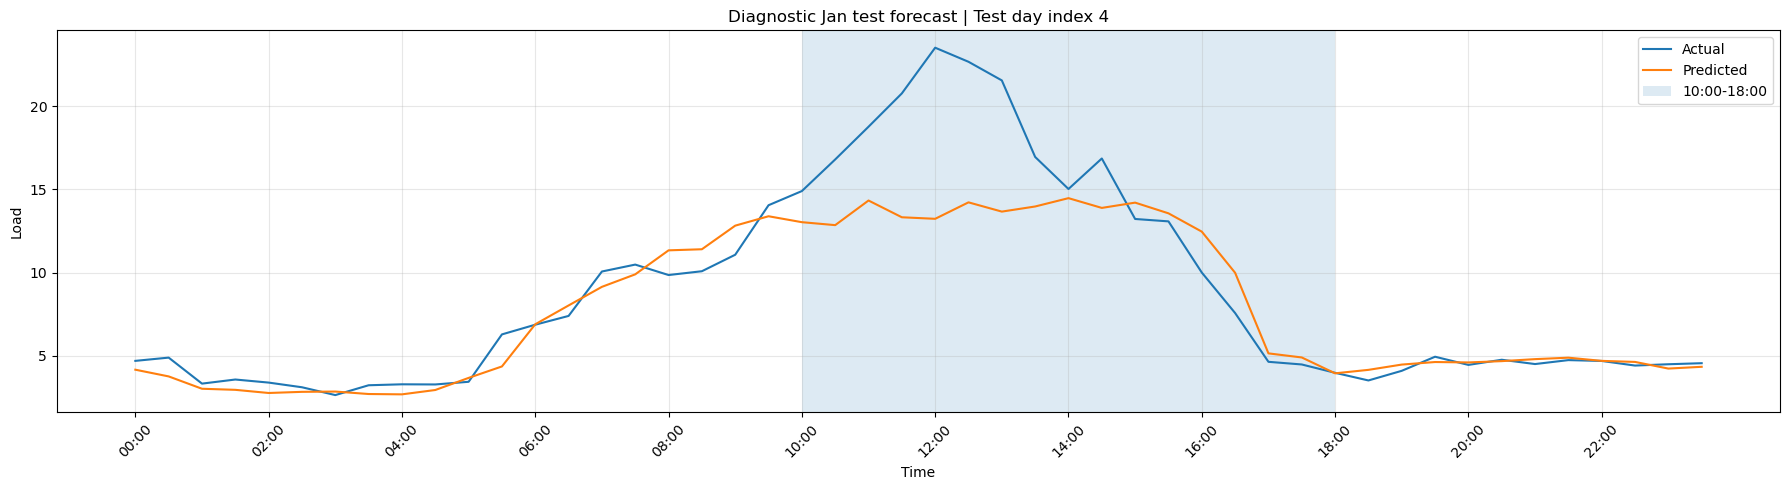

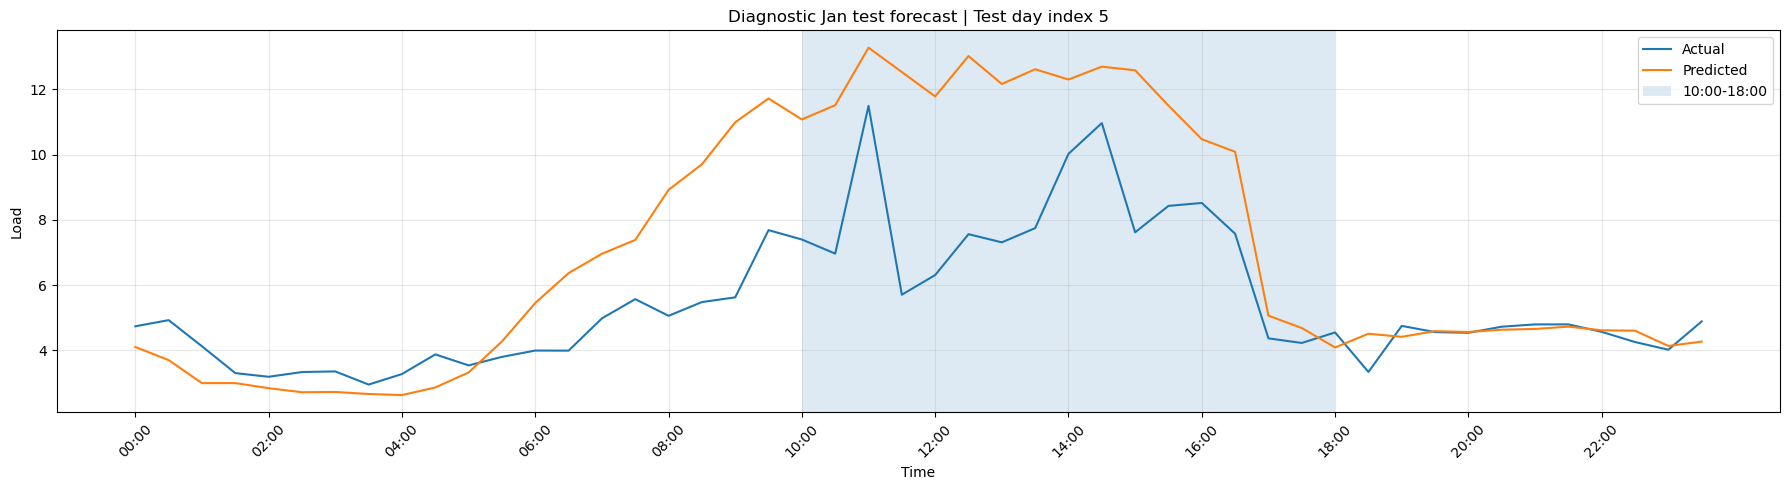

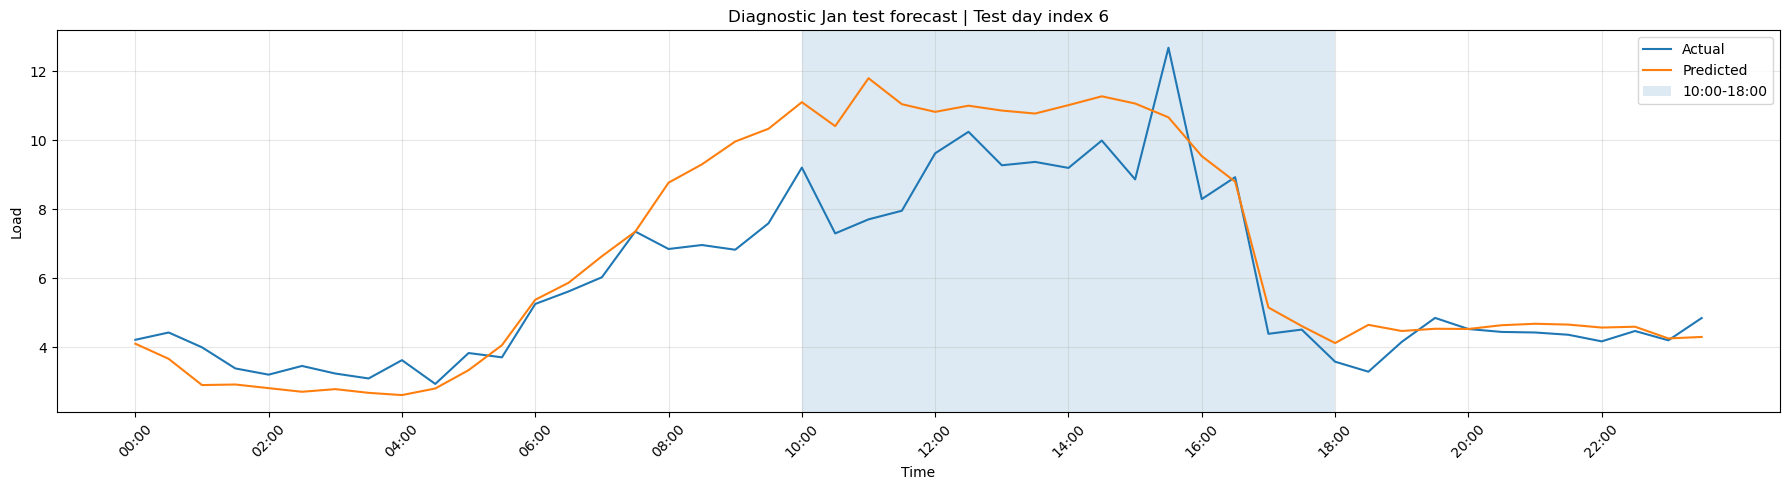

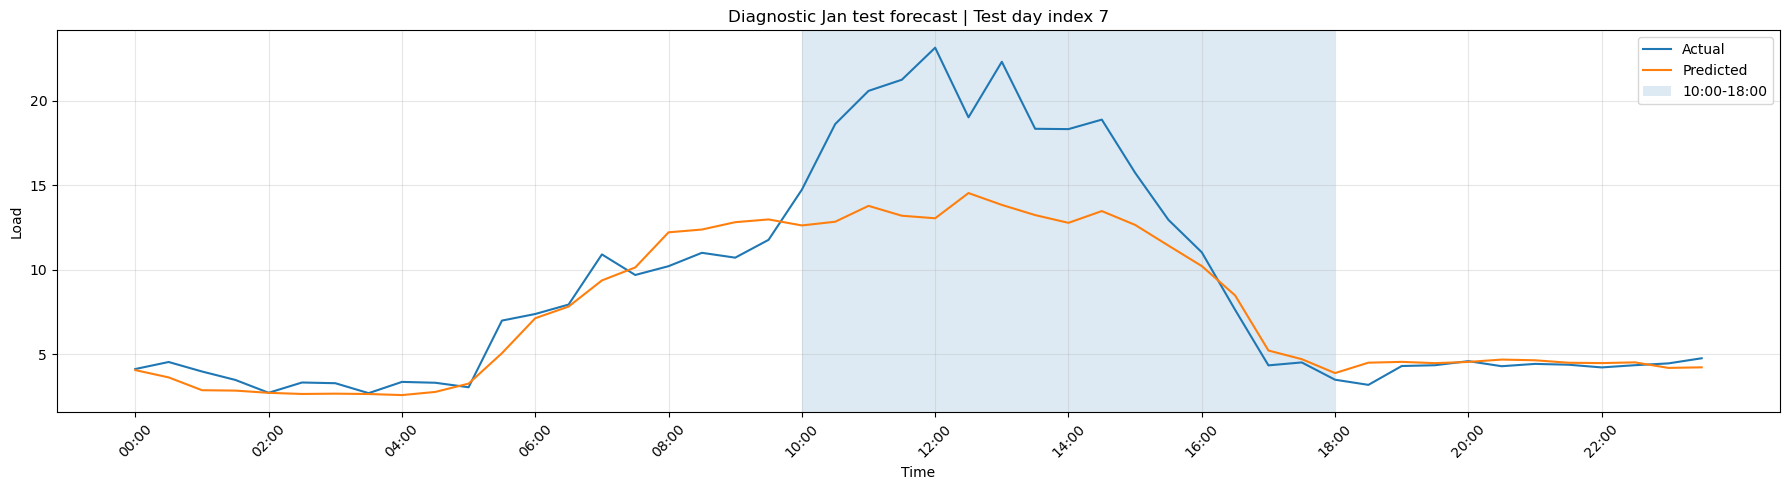

In [16]:
import matplotlib.pyplot as plt
def plot_profile_day(Y_test, Y_pred, day_idx=0, start_hour=10, end_hour=18):
    y_true = Y_test.iloc[day_idx].values.astype(float)
    y_pred_day = Y_pred[day_idx].astype(float)

    times = pd.date_range(start="00:00", periods=48, freq="30min").strftime("%H:%M")

    start_idx = (start_hour * 60) // 30
    end_idx = (end_hour * 60) // 30

    plt.figure(figsize=(18, 5))
    plt.plot(times, y_true, label="Actual")
    plt.plot(times, y_pred_day, label="Predicted")
    plt.axvspan(start_idx, end_idx, alpha=0.15, label=f"{start_hour:02d}:00-{end_hour:02d}:00")

    plt.title(f"Diagnostic Jan test forecast | Test day index {day_idx}")
    plt.xlabel("Time")
    plt.ylabel("Load")
    plt.xticks(range(0, 48, 4), times[::4], rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


for i in range(len(Y_test_jan)):
    plot_profile_day(Y_test_jan, Y_pred_jan, day_idx=i, start_hour=10, end_hour=18)

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0)
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def smape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (denom != 0)
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


def daily_energy_kwh(profile_kw, freq_minutes=15):
    profile_kw = np.asarray(profile_kw, dtype=float)
    return np.nansum(profile_kw) * (freq_minutes / 60)


def time_to_step(hour, minute=0, freq_minutes=15):
    return (hour * 60 + minute) // freq_minutes + 1


def get_window_indices(Y_test, start_hour=10, end_hour=18, freq_minutes=15):
    """
    Window: start_hour <= time < end_hour
    Example: 10–18 means 10:00 to 17:45.
    """
    start_step = time_to_step(start_hour, 0, freq_minutes)
    end_step = time_to_step(end_hour, 0, freq_minutes) - 1

    cols = [f"y_tplus_{s:03d}" for s in range(start_step, end_step + 1)]
    idx = [Y_test.columns.get_loc(c) for c in cols]

    return idx, cols, start_step, end_step


def evaluate_one_vector(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    yt = y_true[mask]
    yp = y_pred[mask]

    if len(yt) == 0:
        return {
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "sMAPE": np.nan,
            "R2": np.nan,
            "bias_pred_minus_actual": np.nan,
        }

    return {
        "MAE": mean_absolute_error(yt, yp),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "MAPE": mape_safe(yt, yp),
        "sMAPE": smape_safe(yt, yp),
        "R2": r2_score(yt, yp) if len(yt) > 1 else np.nan,
        "bias_pred_minus_actual": np.mean(yp - yt),
    }


def daily_error_table(
    Y_test,
    Y_pred,
    *,
    freq_minutes=15,
    peak_start_hour=10,
    peak_end_hour=18,
):
    """
    Creates one row per forecast day with:
    - full-day error
    - peak-window error
    - daily energy error
    - peak max error
    """

    peak_idx, peak_cols, peak_start_step, peak_end_step = get_window_indices(
        Y_test,
        start_hour=peak_start_hour,
        end_hour=peak_end_hour,
        freq_minutes=freq_minutes,
    )

    rows = []

    for i in range(len(Y_test)):
        y_true_full = Y_test.iloc[i].values.astype(float)
        y_pred_full = Y_pred[i].astype(float)

        y_true_peak = y_true_full[peak_idx]
        y_pred_peak = y_pred_full[peak_idx]

        full_metrics = evaluate_one_vector(y_true_full, y_pred_full)
        peak_metrics = evaluate_one_vector(y_true_peak, y_pred_peak)

        actual_energy = daily_energy_kwh(y_true_full, freq_minutes)
        pred_energy = daily_energy_kwh(y_pred_full, freq_minutes)

        rows.append({
            "day_idx": i,
            "issue_time": Y_test.index[i],
            "forecast_day": (Y_test.index[i] + pd.Timedelta(days=1)).normalize(),

            # Full-day metrics
            "full_MAE": full_metrics["MAE"],
            "full_RMSE": full_metrics["RMSE"],
            "full_MAPE": full_metrics["MAPE"],
            "full_sMAPE": full_metrics["sMAPE"],
            "full_R2": full_metrics["R2"],
            "full_bias_pred_minus_actual": full_metrics["bias_pred_minus_actual"],

            # Peak-window metrics
            "peak_window": f"{peak_start_hour:02d}:00-{peak_end_hour:02d}:00",
            "peak_MAE": peak_metrics["MAE"],
            "peak_RMSE": peak_metrics["RMSE"],
            "peak_MAPE": peak_metrics["MAPE"],
            "peak_sMAPE": peak_metrics["sMAPE"],
            "peak_R2": peak_metrics["R2"],
            "peak_bias_pred_minus_actual": peak_metrics["bias_pred_minus_actual"],

            # Energy
            "actual_energy_kwh": actual_energy,
            "pred_energy_kwh": pred_energy,
            "energy_error_kwh_pred_minus_actual": pred_energy - actual_energy,
            "energy_abs_error_kwh": abs(pred_energy - actual_energy),
            "energy_pct_error": (
                abs(pred_energy - actual_energy) / actual_energy * 100
                if actual_energy != 0 else np.nan
            ),

            # Peak max
            "actual_daily_max": np.nanmax(y_true_full),
            "pred_daily_max": np.nanmax(y_pred_full),
            "daily_max_error_pred_minus_actual": np.nanmax(y_pred_full) - np.nanmax(y_true_full),

            "actual_peak_window_max": np.nanmax(y_true_peak),
            "pred_peak_window_max": np.nanmax(y_pred_peak),
            "peak_window_max_error_pred_minus_actual": np.nanmax(y_pred_peak) - np.nanmax(y_true_peak),

            "actual_peak_window_mean": np.nanmean(y_true_peak),
            "pred_peak_window_mean": np.nanmean(y_pred_peak),
        })

    return pd.DataFrame(rows)

In [19]:
jan_daily_errors = daily_error_table(
    Y_test_jan,
    Y_pred_jan,
    freq_minutes=30,
    peak_start_hour=10,
    peak_end_hour=18,
)

jan_daily_errors

,day_idx,issue_time,forecast_day,full_MAE,full_RMSE,full_MAPE,full_sMAPE,full_R2,full_bias_pred_minus_actual,peak_window,...,energy_abs_error_kwh,energy_pct_error,actual_daily_max,pred_daily_max,daily_max_error_pred_minus_actual,actual_peak_window_max,pred_peak_window_max,peak_window_max_error_pred_minus_actual,actual_peak_window_mean,pred_peak_window_mean
0,0,2026-01-18 23:30:00,2026-01-19,0.712739,0.983498,10.076750,10.364089,0.936172,-0.159363,10:00-18:00,...,3.824702,2.138047,16.12517,13.774587,-2.350583,16.12517,13.774587,-2.350583,11.371740,11.180345
1,1,2026-01-19 23:30:00,2026-01-20,1.399211,1.641327,18.411279,20.576949,0.834102,-1.009928,10:00-18:00,...,24.238260,11.795829,16.44050,14.030426,-2.410074,16.44050,14.030426,-2.410074,12.347431,11.775603
2,2,2026-01-20 23:30:00,2026-01-21,1.418668,1.957047,17.112702,17.802942,0.849726,-0.716648,10:00-18:00,...,17.199550,8.265454,20.01433,14.568826,-5.445504,20.01433,14.568826,-5.445504,13.383053,12.351662
3,3,2026-01-21 23:30:00,2026-01-22,2.053668,3.154011,16.419084,18.215957,0.774192,-1.872249,10:00-18:00,...,44.933979,19.823923,21.87400,14.492927,-7.381073,21.87400,14.492927,-7.381073,16.931844,12.091573
4,4,2026-01-22 23:30:00,2026-01-23,1.573994,2.822167,13.662299,14.734004,0.782279,-0.958967,10:00-18:00,...,23.015219,10.983460,23.52450,14.479123,-9.045377,23.52450,14.479123,-9.045377,15.054948,12.332899
5,5,2026-01-23 23:30:00,2026-01-24,1.901071,2.681487,31.500727,25.641043,-0.708414,1.535621,10:00-18:00,...,36.854913,28.032578,11.49717,13.279574,1.782404,11.49717,13.279574,1.782404,7.641384,11.088806
6,6,2026-01-24 23:30:00,2026-01-25,1.014462,1.419454,15.988641,14.935723,0.663063,0.634939,10:00-18:00,...,15.238536,10.714625,12.68800,11.802633,-0.885367,12.68800,11.802633,-0.885367,8.598178,9.999190
7,7,2026-01-25 23:30:00,2026-01-26,1.868769,3.116849,15.734142,17.225070,0.755426,-1.349010,10:00-18:00,...,32.376246,15.169397,23.12050,14.532723,-8.587777,23.12050,14.532723,-8.587777,15.705343,11.627432


In [20]:
jan_daily_errors[
    [
        "day_idx",
        "forecast_day",
        "full_MAE",
        "full_MAPE",
        "peak_MAE",
        "peak_MAPE",
        "peak_bias_pred_minus_actual",
        "actual_peak_window_mean",
        "pred_peak_window_mean",
        "actual_peak_window_max",
        "pred_peak_window_max",
        "energy_pct_error",
    ]
]

,day_idx,forecast_day,full_MAE,full_MAPE,peak_MAE,peak_MAPE,peak_bias_pred_minus_actual,actual_peak_window_mean,pred_peak_window_mean,actual_peak_window_max,pred_peak_window_max,energy_pct_error
0,0,2026-01-19,0.712739,10.076750,1.100641,9.607832,-0.191395,11.371740,11.180345,16.12517,13.774587,2.138047
1,1,2026-01-20,1.399211,18.411279,1.703377,13.515175,-0.571828,12.347431,11.775603,16.44050,14.030426,11.795829
2,2,2026-01-21,1.418668,17.112702,2.295363,20.162561,-1.031391,13.383053,12.351662,20.01433,14.568826,8.265454
3,3,2026-01-22,2.053668,16.419084,4.884278,26.534291,-4.840271,16.931844,12.091573,21.87400,14.492927,19.823923
4,4,2026-01-23,1.573994,13.662299,3.631518,21.247988,-2.722049,15.054948,12.332899,23.52450,14.479123,10.983460
5,5,2026-01-24,1.901071,31.500727,3.447422,47.566676,3.447422,7.641384,11.088806,11.49717,13.279574,28.032578
6,6,2026-01-25,1.014462,15.988641,1.669611,19.793778,1.401012,8.598178,9.999190,12.68800,11.802633,10.714625
7,7,2026-01-26,1.868769,15.734142,4.318159,23.889490,-4.077911,15.705343,11.627432,23.12050,14.532723,15.169397


In [35]:
daily = daily_error_table(
    Y_test,
    Y_pred_unweighted,
    freq_minutes=15,
    peak_start_hour=10,
    peak_end_hour=18,
)

# Define regimes based on actual peak-window max
q75 = daily["actual_peak_window_max"].quantile(0.75)
q90 = daily["actual_peak_window_max"].quantile(0.90)

daily["regime"] = "normal"
daily.loc[daily["actual_peak_window_max"] >= q75, "regime"] = "high_peak"
daily.loc[daily["actual_peak_window_max"] >= q90, "regime"] = "extreme_peak"

regime_summary = (
    daily
    .groupby("regime")
    .agg(
        n_days=("day_idx", "count"),
        mean_full_MAE=("full_MAE", "mean"),
        mean_peak_MAE=("peak_MAE", "mean"),
        mean_peak_MAPE=("peak_MAPE", "mean"),
        mean_peak_bias=("peak_bias_pred_minus_actual", "mean"),
        actual_peak_mean=("actual_peak_window_mean", "mean"),
        pred_peak_mean=("pred_peak_window_mean", "mean"),
        actual_peak_max=("actual_peak_window_max", "mean"),
        pred_peak_max=("pred_peak_window_max", "mean"),
    )
    .reset_index()
)

regime_summary

NameError: name 'Y_test' is not defined

## weighted day training

In [ ]:
X, Y_full = build_day_ahead_profile_dataset(
    df_imputed,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    drop_feature_nan=False,
    drop_target_nan=True,
)

print("X shape:", X.shape)
print("Y_full shape:", Y_full.shape)
print("First issue time:", X.index.min())
print("Last issue time:", X.index.max())

In [ ]:
test_issue_start = pd.Timestamp("2026-01-31 23:45:00")
test_issue_end   = pd.Timestamp("2026-02-07 23:45:00")

train_mask = X.index < test_issue_start
test_mask = (X.index >= test_issue_start) & (X.index <= test_issue_end)

X_train = X.loc[train_mask].copy()
Y_train = Y_full.loc[train_mask].copy()

X_test = X.loc[test_mask].copy()
Y_test = Y_full.loc[test_mask].copy()

print("Train issue range:", X_train.index.min(), "to", X_train.index.max())
print("Test issue range :", X_test.index.min(), "to", X_test.index.max())

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test :", X_test.shape)
print("Y_test :", Y_test.shape)

In [ ]:
def make_recent_weights(index, min_weight=1.0, max_weight=3.0):
    """
    Oldest training day gets min_weight.
    Newest training day gets max_weight.
    """
    n = len(index)

    if n == 0:
        raise ValueError("Index is empty.")

    if n == 1:
        return np.array([max_weight], dtype=float)

    return np.linspace(min_weight, max_weight, n)


def train_multioutput_xgb_with_weights(X_train, Y_train, sample_weight=None, random_state=42):
    """
    Train one XGBoost model per horizon.
    This makes sample_weight handling clear.
    """
    models = {}

    for col in Y_train.columns:
        model = XGBRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            reg_lambda=2.0,
            objective="reg:squarederror",
            random_state=random_state,
            n_jobs=-1,
        )

        model.fit(
            X_train,
            Y_train[col],
            sample_weight=sample_weight,
        )

        models[col] = model

    return models


def predict_multioutput_xgb(models, X):
    preds = []

    for col in models:
        preds.append(models[col].predict(X))

    return np.column_stack(preds)


def evaluate_peak_window(Y_test, Y_pred, start_step=41, end_step=72):
    """
    Evaluate only 10:00–18:00 peak window.
    For 15-min data:
    step 41 = 10:00
    step 72 = 17:45
    """
    peak_cols = [f"y_tplus_{s:03d}" for s in range(start_step, end_step + 1)]
    peak_indices = [Y_test.columns.get_loc(c) for c in peak_cols]

    y_true = Y_test.iloc[:, peak_indices].values.ravel()
    y_pred = Y_pred[:, peak_indices].ravel()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mape_mask = y_true != 0

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_mask = denom != 0

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": np.mean(np.abs((y_true[mape_mask] - y_pred[mape_mask]) / y_true[mape_mask])) * 100,
        "sMAPE": np.mean(np.abs(y_true[smape_mask] - y_pred[smape_mask]) / denom[smape_mask]) * 100,
        "R2": r2_score(y_true, y_pred),
        "mean_bias_pred_minus_actual": np.mean(y_pred - y_true),
        "actual_mean": np.mean(y_true),
        "pred_mean": np.mean(y_pred),
        "actual_max": np.max(y_true),
        "pred_max": np.max(y_pred),
    }

In [ ]:
recent_weights = make_recent_weights(
    X_train.index,
    min_weight=1.0,
    max_weight=3.0,
)

print("Recent weights shape:", recent_weights.shape)
print("First 5 weights:", recent_weights[:5])
print("Last 5 weights:", recent_weights[-5:])
print("Mean weight:", recent_weights.mean())

In [ ]:
models_unweighted = train_multioutput_xgb_with_weights(
    X_train,
    Y_train,
    sample_weight=None,
    random_state=42,
)

models_recent_weighted = train_multioutput_xgb_with_weights(
    X_train,
    Y_train,
    sample_weight=recent_weights,
    random_state=42,
)

In [ ]:
Y_pred_unweighted = predict_multioutput_xgb(models_unweighted, X_test)
Y_pred_recent = predict_multioutput_xgb(models_recent_weighted, X_test)

print("Y_pred_unweighted:", Y_pred_unweighted.shape)
print("Y_pred_recent:", Y_pred_recent.shape)

In [ ]:
unweighted_full_metrics = evaluate_profile_global(Y_test, Y_pred_unweighted)
recent_full_metrics = evaluate_profile_global(Y_test, Y_pred_recent)

full_comparison = pd.DataFrame([
    {
        "experiment": "unweighted_train_until_feb1",
        **unweighted_full_metrics,
    },
    {
        "experiment": "recent_weighted_train_until_feb1",
        **recent_full_metrics,
    },
])

full_comparison

In [ ]:
unweighted_peak_metrics = evaluate_peak_window(
    Y_test,
    Y_pred_unweighted,
    start_step=41,
    end_step=72,
)

recent_peak_metrics = evaluate_peak_window(
    Y_test,
    Y_pred_recent,
    start_step=41,
    end_step=72,
)

peak_comparison = pd.DataFrame([
    {
        "experiment": "unweighted_peak_window",
        **unweighted_peak_metrics,
    },
    {
        "experiment": "recent_weighted_peak_window",
        **recent_peak_metrics,
    },
])

peak_comparison

In [ ]:
import matplotlib.pyplot as plt

def plot_prediction_comparison_day(Y_test, pred_a, pred_b, day_idx=0):
    y_true = Y_test.iloc[day_idx].values.astype(float)
    y_a = pred_a[day_idx].astype(float)
    y_b = pred_b[day_idx].astype(float)

    times = pd.date_range(start="00:00", periods=96, freq="15min").strftime("%H:%M")

    plt.figure(figsize=(18, 5))
    plt.plot(times, y_true, label="Actual")
    plt.plot(times, y_a, label="Unweighted")
    plt.plot(times, y_b, label="Recent-weighted")
    plt.axvspan(40, 72, alpha=0.15, label="Peak window")

    plt.title(f"Full-day forecast comparison | Test day index {day_idx}")
    plt.xlabel("Time")
    plt.ylabel("Load")
    plt.xticks(times[::4], rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


for i in range(len(Y_test)):
    plot_prediction_comparison_day(
        Y_test,
        Y_pred_unweighted,
        Y_pred_recent,
        day_idx=i,
    )

In [ ]:
def time_to_step(hour, minute=0, freq_minutes=15):
    """
    Converts time of day to 1-based horizon step.
    Assumption:
    y_tplus_001 = 00:00
    y_tplus_002 = 00:15
    ...
    """
    minutes = hour * 60 + minute
    return minutes // freq_minutes + 1


def evaluate_window(Y_test, Y_pred, start_hour, end_hour, freq_minutes=15):
    """
    Evaluate window start_hour <= time < end_hour.
    Example:
    start_hour=10, end_hour=18 evaluates 10:00 to 17:45.
    """
    start_step = time_to_step(start_hour, 0, freq_minutes)
    end_step = time_to_step(end_hour, 0, freq_minutes) - 1

    cols = [f"y_tplus_{s:03d}" for s in range(start_step, end_step + 1)]
    idx = [Y_test.columns.get_loc(c) for c in cols]

    y_true = Y_test.iloc[:, idx].values.ravel()
    y_pred = Y_pred[:, idx].ravel()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mape_mask = y_true != 0
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_mask = denom != 0

    return {
        "window": f"{start_hour:02d}:00-{end_hour:02d}:00",
        "start_step": start_step,
        "end_step": end_step,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": np.mean(np.abs((y_true[mape_mask] - y_pred[mape_mask]) / y_true[mape_mask])) * 100,
        "sMAPE": np.mean(np.abs(y_true[smape_mask] - y_pred[smape_mask]) / denom[smape_mask]) * 100,
        "R2": r2_score(y_true, y_pred),
        "bias_pred_minus_actual": np.mean(y_pred - y_true),
        "actual_mean": np.mean(y_true),
        "pred_mean": np.mean(y_pred),
        "actual_max": np.max(y_true),
        "pred_max": np.max(y_pred),
    }


windows = [
    (8, 17),
    (9, 17),
    (10, 17),
    (10, 18),
]

rows = []

for start_h, end_h in windows:
    rows.append({
        "experiment": "unweighted",
        **evaluate_window(Y_test, Y_pred_unweighted, start_h, end_h),
    })

    rows.append({
        "experiment": "recent_weighted",
        **evaluate_window(Y_test, Y_pred_recent, start_h, end_h),
    })

window_comparison = pd.DataFrame(rows)
window_comparison

In [ ]:
def plot_prediction_comparison_day_with_window(
    Y_test,
    pred_a,
    pred_b,
    day_idx=0,
    start_hour=9,
    end_hour=17,
):
    y_true = Y_test.iloc[day_idx].values.astype(float)
    y_a = pred_a[day_idx].astype(float)
    y_b = pred_b[day_idx].astype(float)

    times = pd.date_range(start="00:00", periods=96, freq="15min").strftime("%H:%M")

    start_idx = (start_hour * 60) // 15
    end_idx = (end_hour * 60) // 15

    plt.figure(figsize=(18, 5))
    plt.plot(times, y_true, label="Actual")
    plt.plot(times, y_a, label="Unweighted")
    plt.plot(times, y_b, label="Recent-weighted")

    plt.axvspan(start_idx, end_idx, alpha=0.15, label=f"{start_hour:02d}:00-{end_hour:02d}:00 window")

    plt.title(f"Full-day forecast comparison | Test day index {day_idx}")
    plt.xlabel("Time")
    plt.ylabel("Load")
    plt.xticks(range(0, 96, 4), times[::4], rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


for i in range(len(Y_test)):
    plot_prediction_comparison_day_with_window(
        Y_test,
        Y_pred_unweighted,
        Y_pred_recent,
        day_idx=i,
        start_hour=9,
        end_hour=17,
    )

## Isotonic Recalibration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.profile_dataset_builder import build_day_ahead_profile_dataset
from src.profile_metrics import evaluate_profile_global

In [ ]:
target_col = "BU_TotActPwr_Academy"
feature_col = [c for c in df_imputed.columns if c != target_col]
# or:
# target_col = "BU_TotActPwr_SDB_EL_Substation"

X, Y_full = build_day_ahead_profile_dataset(
    df_imputed,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    drop_feature_nan=False,
    drop_target_nan=True,
)

print("X shape:", X.shape)
print("Y_full shape:", Y_full.shape)
print("Issue range:", X.index.min(), "to", X.index.max())

In [ ]:
# Calibration target days: Jan 22 to Jan 31
calib_issue_start = pd.Timestamp("2026-01-21 23:45:00")
calib_issue_end   = pd.Timestamp("2026-01-30 23:45:00")

# Test target days: Feb 1 to Feb 8
test_issue_start = pd.Timestamp("2026-01-31 23:45:00")
test_issue_end   = pd.Timestamp("2026-02-07 23:45:00")

train_mask = X.index < calib_issue_start
calib_mask = (X.index >= calib_issue_start) & (X.index <= calib_issue_end)
test_mask = (X.index >= test_issue_start) & (X.index <= test_issue_end)

X_train = X.loc[train_mask].copy()
Y_train = Y_full.loc[train_mask].copy()

X_calib = X.loc[calib_mask].copy()
Y_calib = Y_full.loc[calib_mask].copy()

X_test = X.loc[test_mask].copy()
Y_test = Y_full.loc[test_mask].copy()

print("Train issue range:", X_train.index.min(), "to", X_train.index.max())
print("Calib issue range:", X_calib.index.min(), "to", X_calib.index.max())
print("Test issue range :", X_test.index.min(), "to", X_test.index.max())

print("\nShapes:")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_calib:", X_calib.shape, "Y_calib:", Y_calib.shape)
print("X_test :", X_test.shape, "Y_test :", Y_test.shape)

In [ ]:
xgb_base = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=2.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

model = MultiOutputRegressor(xgb_base)

model.fit(X_train, Y_train)

Y_calib_pred_raw = model.predict(X_calib)
Y_test_pred_raw = model.predict(X_test)

print("Y_calib_pred_raw:", Y_calib_pred_raw.shape)
print("Y_test_pred_raw:", Y_test_pred_raw.shape)

In [ ]:
def mape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0)

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def smape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (denom != 0)

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


def evaluate_arrays(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape_safe(y_true, y_pred),
        "sMAPE": smape_safe(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "bias_pred_minus_actual": np.mean(y_pred - y_true),
        "actual_mean": np.mean(y_true),
        "pred_mean": np.mean(y_pred),
        "actual_max": np.max(y_true),
        "pred_max": np.max(y_pred),
    }


def time_to_step(hour, minute=0, freq_minutes=15):
    """
    y_tplus_001 = 00:00
    """
    return (hour * 60 + minute) // freq_minutes + 1


def get_window_indices(Y, start_hour=10, end_hour=18, freq_minutes=15):
    """
    Window: start_hour <= time < end_hour.
    Example 10–18 gives 10:00 to 17:45.
    """
    start_step = time_to_step(start_hour, 0, freq_minutes)
    end_step = time_to_step(end_hour, 0, freq_minutes) - 1

    cols = [f"y_tplus_{s:03d}" for s in range(start_step, end_step + 1)]
    indices = [Y.columns.get_loc(c) for c in cols]

    return indices, cols, start_step, end_step


def evaluate_window(Y_true_df, Y_pred_array, start_hour=10, end_hour=18):
    idx, cols, start_step, end_step = get_window_indices(
        Y_true_df,
        start_hour=start_hour,
        end_hour=end_hour,
    )

    y_true = Y_true_df.iloc[:, idx].values
    y_pred = Y_pred_array[:, idx]

    metrics = evaluate_arrays(y_true, y_pred)

    return {
        "window": f"{start_hour:02d}:00-{end_hour:02d}:00",
        "start_step": start_step,
        "end_step": end_step,
        **metrics,
    }

In [ ]:
def mape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0)

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def smape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (denom != 0)

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


def evaluate_arrays(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape_safe(y_true, y_pred),
        "sMAPE": smape_safe(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "bias_pred_minus_actual": np.mean(y_pred - y_true),
        "actual_mean": np.mean(y_true),
        "pred_mean": np.mean(y_pred),
        "actual_max": np.max(y_true),
        "pred_max": np.max(y_pred),
    }


def time_to_step(hour, minute=0, freq_minutes=15):
    """
    y_tplus_001 = 00:00
    """
    return (hour * 60 + minute) // freq_minutes + 1


def get_window_indices(Y, start_hour=10, end_hour=18, freq_minutes=15):
    """
    Window: start_hour <= time < end_hour.
    Example 10–18 gives 10:00 to 17:45.
    """
    start_step = time_to_step(start_hour, 0, freq_minutes)
    end_step = time_to_step(end_hour, 0, freq_minutes) - 1

    cols = [f"y_tplus_{s:03d}" for s in range(start_step, end_step + 1)]
    indices = [Y.columns.get_loc(c) for c in cols]

    return indices, cols, start_step, end_step


def evaluate_window(Y_true_df, Y_pred_array, start_hour=10, end_hour=18):
    idx, cols, start_step, end_step = get_window_indices(
        Y_true_df,
        start_hour=start_hour,
        end_hour=end_hour,
    )

    y_true = Y_true_df.iloc[:, idx].values
    y_pred = Y_pred_array[:, idx]

    metrics = evaluate_arrays(y_true, y_pred)

    return {
        "window": f"{start_hour:02d}:00-{end_hour:02d}:00",
        "start_step": start_step,
        "end_step": end_step,
        **metrics,
    }

In [ ]:
def fit_global_isotonic_for_window(
    Y_calib,
    Y_calib_pred_raw,
    start_hour=10,
    end_hour=18,
):
    idx, cols, start_step, end_step = get_window_indices(
        Y_calib,
        start_hour=start_hour,
        end_hour=end_hour,
    )

    y_true_calib = Y_calib.iloc[:, idx].values.ravel()
    y_pred_calib = Y_calib_pred_raw[:, idx].ravel()

    mask = np.isfinite(y_true_calib) & np.isfinite(y_pred_calib)

    x = y_pred_calib[mask]
    y = y_true_calib[mask]

    iso = IsotonicRegression(
        increasing=True,
        out_of_bounds="clip"
    )

    iso.fit(x, y)

    info = {
        "window": f"{start_hour:02d}:00-{end_hour:02d}:00",
        "n_calibration_points": len(x),
        "raw_pred_min": np.min(x),
        "raw_pred_max": np.max(x),
        "actual_min": np.min(y),
        "actual_max": np.max(y),
        "raw_pred_mean": np.mean(x),
        "actual_mean": np.mean(y),
        "calib_bias_raw_pred_minus_actual": np.mean(x - y),
    }

    return iso, info


iso_model, iso_info = fit_global_isotonic_for_window(
    Y_calib,
    Y_calib_pred_raw,
    start_hour=10,
    end_hour=18,
)

iso_info

In [ ]:
def apply_global_isotonic_to_window(
    Y_pred_raw,
    iso_model,
    Y_reference,
    start_hour=10,
    end_hour=18,
):
    Y_pred_corrected = Y_pred_raw.copy()

    idx, cols, start_step, end_step = get_window_indices(
        Y_reference,
        start_hour=start_hour,
        end_hour=end_hour,
    )

    raw_values = Y_pred_corrected[:, idx].ravel()

    corrected_values = iso_model.predict(raw_values)

    Y_pred_corrected[:, idx] = corrected_values.reshape(
        Y_pred_corrected[:, idx].shape
    )

    return Y_pred_corrected


Y_test_pred_iso = apply_global_isotonic_to_window(
    Y_test_pred_raw,
    iso_model,
    Y_test,
    start_hour=10,
    end_hour=18,
)

In [ ]:
raw_full_metrics = evaluate_arrays(Y_test.values, Y_test_pred_raw)
iso_full_metrics = evaluate_arrays(Y_test.values, Y_test_pred_iso)

full_day_iso_comparison = pd.DataFrame([
    {
        "experiment": "raw_xgboost_full_day",
        **raw_full_metrics,
    },
    {
        "experiment": "isotonic_corrected_peak_window_full_day",
        **iso_full_metrics,
    },
])

full_day_iso_comparison

In [ ]:
raw_peak_metrics = evaluate_window(
    Y_test,
    Y_test_pred_raw,
    start_hour=10,
    end_hour=18,
)

iso_peak_metrics = evaluate_window(
    Y_test,
    Y_test_pred_iso,
    start_hour=10,
    end_hour=18,
)

peak_iso_comparison = pd.DataFrame([
    {
        "experiment": "raw_xgboost_peak_window",
        **raw_peak_metrics,
    },
    {
        "experiment": "isotonic_corrected_peak_window",
        **iso_peak_metrics,
    },
])

peak_iso_comparison

In [ ]:
iso_model_9_17, iso_info_9_17 = fit_global_isotonic_for_window(
    Y_calib,
    Y_calib_pred_raw,
    start_hour=9,
    end_hour=17,
)

Y_test_pred_iso_9_17 = apply_global_isotonic_to_window(
    Y_test_pred_raw,
    iso_model_9_17,
    Y_test,
    start_hour=9,
    end_hour=17,
)

raw_9_17_metrics = evaluate_window(
    Y_test,
    Y_test_pred_raw,
    start_hour=9,
    end_hour=17,
)

iso_9_17_metrics = evaluate_window(
    Y_test,
    Y_test_pred_iso_9_17,
    start_hour=9,
    end_hour=17,
)

iso_window_comparison = pd.DataFrame([
    {
        "experiment": "raw_09_17",
        **raw_9_17_metrics,
    },
    {
        "experiment": "isotonic_09_17",
        **iso_9_17_metrics,
    },
])

iso_window_comparison

In [ ]:
def plot_iso_comparison_day(
    Y_test,
    Y_pred_raw,
    Y_pred_iso,
    day_idx=0,
    start_hour=10,
    end_hour=18,
):
    y_true = Y_test.iloc[day_idx].values.astype(float)
    y_raw = Y_pred_raw[day_idx].astype(float)
    y_iso = Y_pred_iso[day_idx].astype(float)

    times = pd.date_range(start="00:00", periods=96, freq="15min").strftime("%H:%M")

    start_idx = (start_hour * 60) // 15
    end_idx = (end_hour * 60) // 15

    plt.figure(figsize=(18, 5))
    plt.plot(times, y_true, label="Actual")
    plt.plot(times, y_raw, label="Raw XGBoost")
    plt.plot(times, y_iso, label="Isotonic corrected")

    plt.axvspan(
        start_idx,
        end_idx,
        alpha=0.15,
        label=f"{start_hour:02d}:00-{end_hour:02d}:00 correction window"
    )

    plt.title(f"Isotonic recalibration comparison | Test day index {day_idx}")
    plt.xlabel("Time")
    plt.ylabel("Load")
    plt.xticks(range(0, 96, 4), times[::4], rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


for i in range(len(Y_test)):
    plot_iso_comparison_day(
        Y_test,
        Y_test_pred_raw,
        Y_test_pred_iso,
        day_idx=i,
        start_hour=10,
        end_hour=18,
    )

In [ ]:
def daily_window_bias_table(
    Y_test,
    Y_pred_raw,
    Y_pred_iso,
    start_hour=10,
    end_hour=18,
):
    idx, cols, start_step, end_step = get_window_indices(
        Y_test,
        start_hour=start_hour,
        end_hour=end_hour,
    )

    rows = []

    for i in range(len(Y_test)):
        y_true = Y_test.iloc[i, idx].values.astype(float)
        y_raw = Y_pred_raw[i, idx].astype(float)
        y_iso = Y_pred_iso[i, idx].astype(float)

        rows.append({
            "day_idx": i,
            "issue_time": Y_test.index[i],
            "window": f"{start_hour:02d}:00-{end_hour:02d}:00",

            "actual_mean": np.mean(y_true),
            "raw_pred_mean": np.mean(y_raw),
            "iso_pred_mean": np.mean(y_iso),

            "raw_bias": np.mean(y_raw - y_true),
            "iso_bias": np.mean(y_iso - y_true),

            "actual_max": np.max(y_true),
            "raw_pred_max": np.max(y_raw),
            "iso_pred_max": np.max(y_iso),

            "raw_peak_max_error": np.max(y_raw) - np.max(y_true),
            "iso_peak_max_error": np.max(y_iso) - np.max(y_true),

            "raw_MAE": mean_absolute_error(y_true, y_raw),
            "iso_MAE": mean_absolute_error(y_true, y_iso),
        })

    return pd.DataFrame(rows)


iso_daily_bias = daily_window_bias_table(
    Y_test,
    Y_test_pred_raw,
    Y_test_pred_iso,
    start_hour=10,
    end_hour=18,
)

iso_daily_bias

## Quantile Forecasting.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.profile_dataset_builder import build_day_ahead_profile_dataset

In [ ]:
target_col = "BU_TotActPwr_Academy"
feature_cols = [c for c in df_imputed.columns if c != target_col]

X, Y_full = build_day_ahead_profile_dataset(
    df_imputed,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    drop_feature_nan=False,
    drop_target_nan=True,
)

print("X shape:", X.shape)
print("Y_full shape:", Y_full.shape)
print("Issue range:", X.index.min(), "to", X.index.max())

In [ ]:
test_issue_start = pd.Timestamp("2026-01-31 23:45:00")
test_issue_end   = pd.Timestamp("2026-02-07 23:45:00")

train_mask = X.index < test_issue_start
test_mask = (X.index >= test_issue_start) & (X.index <= test_issue_end)

X_train = X.loc[train_mask].copy()
Y_train_full = Y_full.loc[train_mask].copy()

X_test = X.loc[test_mask].copy()
Y_test_full = Y_full.loc[test_mask].copy()

print("Train issue range:", X_train.index.min(), "to", X_train.index.max())
print("Test issue range :", X_test.index.min(), "to", X_test.index.max())

print("X_train:", X_train.shape)
print("Y_train_full:", Y_train_full.shape)
print("X_test:", X_test.shape)
print("Y_test_full:", Y_test_full.shape)

In [ ]:
def time_to_step(hour, minute=0, freq_minutes=15):
    """
    y_tplus_001 = 00:00
    y_tplus_041 = 10:00
    """
    return (hour * 60 + minute) // freq_minutes + 1


def get_window_cols(start_hour=10, end_hour=18, freq_minutes=15):
    """
    Window start_hour <= time < end_hour.
    Example 10–18 means 10:00 to 17:45.
    """
    start_step = time_to_step(start_hour, 0, freq_minutes)
    end_step = time_to_step(end_hour, 0, freq_minutes) - 1

    cols = [f"y_tplus_{s:03d}" for s in range(start_step, end_step + 1)]

    return cols, start_step, end_step


peak_cols, peak_start_step, peak_end_step = get_window_cols(
    start_hour=10,
    end_hour=18,
    freq_minutes=15,
)

Y_train = Y_train_full[peak_cols].copy()
Y_test = Y_test_full[peak_cols].copy()

print("Peak columns:", peak_cols[0], "to", peak_cols[-1])
print("Peak steps:", peak_start_step, "to", peak_end_step)
print("Y_train peak:", Y_train.shape)
print("Y_test peak:", Y_test.shape)

In [ ]:
def train_quantile_models_per_horizon(
    X_train,
    Y_train,
    quantile=0.5,
    random_state=42,
):
    """
    Train one quantile regression model per horizon column.
    """
    models = {}

    for col in Y_train.columns:
        model = HistGradientBoostingRegressor(
            loss="quantile",
            quantile=quantile,
            max_iter=400,
            learning_rate=0.03,
            max_leaf_nodes=15,
            l2_regularization=0.1,
            random_state=random_state,
        )

        model.fit(X_train, Y_train[col])
        models[col] = model

    return models


def predict_models_per_horizon(models, X):
    preds = []

    for col in models:
        preds.append(models[col].predict(X))

    return np.column_stack(preds)


def mape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0)

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def smape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (denom != 0)

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


def evaluate_point_forecast(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape_safe(y_true, y_pred),
        "sMAPE": smape_safe(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "bias_pred_minus_actual": np.mean(y_pred - y_true),
        "actual_mean": np.mean(y_true),
        "pred_mean": np.mean(y_pred),
        "actual_max": np.max(y_true),
        "pred_max": np.max(y_pred),
    }


def pinball_loss(y_true, y_pred, quantile):
    """
    Quantile / pinball loss.
    Lower is better.
    """
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    err = y_true - y_pred

    return np.mean(np.maximum(quantile * err, (quantile - 1) * err))


def coverage_below(y_true, y_pred):
    """
    Percentage of actual values below predicted quantile.
    For q90, ideal coverage is around 90%.
    """
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    return np.mean(y_true <= y_pred) * 100

In [ ]:
quantiles = [0.50, 0.75, 0.90]

quantile_models = {}
quantile_preds = {}

for q in quantiles:
    print(f"Training quantile model q={q}")

    models_q = train_quantile_models_per_horizon(
        X_train,
        Y_train,
        quantile=q,
        random_state=42,
    )

    pred_q = predict_models_per_horizon(models_q, X_test)

    quantile_models[q] = models_q
    quantile_preds[q] = pred_q

print("Done.")

In [ ]:
rows = []

for q in quantiles:
    pred_q = quantile_preds[q]

    point_metrics = evaluate_point_forecast(Y_test.values, pred_q)

    rows.append({
        "forecast": f"q{int(q * 100)}",
        "quantile": q,
        **point_metrics,
        "pinball_loss": pinball_loss(Y_test.values, pred_q, q),
        "coverage_below_%": coverage_below(Y_test.values, pred_q),
    })

quantile_results = pd.DataFrame(rows)
quantile_results

In [ ]:
q50_pred = quantile_preds[0.50]
q75_pred = quantile_preds[0.75]
q90_pred = quantile_preds[0.90]

interval_summary = pd.DataFrame([{
    "mean_q50": np.mean(q50_pred),
    "mean_q75": np.mean(q75_pred),
    "mean_q90": np.mean(q90_pred),
    "mean_q90_minus_q50": np.mean(q90_pred - q50_pred),
    "min_q90_minus_q50": np.min(q90_pred - q50_pred),
    "max_q90_minus_q50": np.max(q90_pred - q50_pred),
}])

interval_summary

In [ ]:
q_preds_stacked = np.stack([q50_pred, q75_pred, q90_pred], axis=0)
q_preds_sorted = np.sort(q_preds_stacked, axis=0)

q50_pred_fixed = q_preds_sorted[0]
q75_pred_fixed = q_preds_sorted[1]
q90_pred_fixed = q_preds_sorted[2]

In [ ]:
def plot_quantile_peak_day(
    Y_test,
    q50_pred,
    q75_pred,
    q90_pred,
    day_idx=0,
    start_hour=10,
    end_hour=18,
):
    y_true = Y_test.iloc[day_idx].values.astype(float)
    y_q50 = q50_pred[day_idx].astype(float)
    y_q75 = q75_pred[day_idx].astype(float)
    y_q90 = q90_pred[day_idx].astype(float)

    times = pd.date_range(
        start=f"{start_hour:02d}:00",
        periods=len(y_true),
        freq="15min"
    ).strftime("%H:%M")

    plt.figure(figsize=(16, 5))

    plt.plot(times, y_true, marker="o", label="Actual")
    plt.plot(times, y_q50, marker="o", label="q50 median forecast")
    plt.plot(times, y_q75, marker="o", label="q75 upper forecast")
    plt.plot(times, y_q90, marker="o", label="q90 conservative forecast")

    plt.fill_between(
        times,
        y_q50,
        y_q90,
        alpha=0.15,
        label="q50–q90 interval"
    )

    plt.title(f"Peak-window quantile forecast | Test day {day_idx}")
    plt.xlabel("Time")
    plt.ylabel("Load")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


for i in range(len(Y_test)):
    plot_quantile_peak_day(
        Y_test,
        q50_pred,
        q75_pred,
        q90_pred,
        day_idx=i,
        start_hour=10,
        end_hour=18,
    )

In [ ]:
def daily_quantile_summary(Y_test, q50_pred, q75_pred, q90_pred):
    rows = []

    for i in range(len(Y_test)):
        y_true = Y_test.iloc[i].values.astype(float)
        y50 = q50_pred[i].astype(float)
        y75 = q75_pred[i].astype(float)
        y90 = q90_pred[i].astype(float)

        rows.append({
            "day_idx": i,
            "issue_time": Y_test.index[i],
            "actual_mean": np.mean(y_true),
            "q50_mean": np.mean(y50),
            "q75_mean": np.mean(y75),
            "q90_mean": np.mean(y90),
            "actual_max": np.max(y_true),
            "q50_max": np.max(y50),
            "q75_max": np.max(y75),
            "q90_max": np.max(y90),
            "q90_coverage_%": coverage_below(y_true, y90),
            "q75_coverage_%": coverage_below(y_true, y75),
            "q50_coverage_%": coverage_below(y_true, y50),
            "q50_MAE": mean_absolute_error(y_true, y50),
            "q75_MAE": mean_absolute_error(y_true, y75),
            "q90_MAE": mean_absolute_error(y_true, y90),
        })

    return pd.DataFrame(rows)


daily_q_summary = daily_quantile_summary(
    Y_test,
    q50_pred,
    q75_pred,
    q90_pred,
)

daily_q_summary